# nb03 — (a) лечится ли хвост?

В nb02 месячный протокол дал: среднее **−0.600%** от gross за сделку при медиане
**+2.18%** и 70.4% плюсовых. То есть спред обычно возвращается, но редкие
невозвраты (худшая сделка −142% от gross) съедают всё.

Вопрос шага: **механика мертва или её просто не защитили?**

1. §1 — диагностика: сколько PnL уносит хвост и кто в нём сидит.
2. §2 — варианты защиты на одном наборе пар-месяцев: фильтр β, z-стоп,
   стоп по убытку, лимит времени, запрет перезахода.
3. §3 — сводка и честный разговор о переборе вариантов.

**Дисциплина:** перебираю ~11 конфигураций на TRAIN. Это подгонка по построению,
поэтому итог — не «доходность стратегии», а ответ да/нет про хвост. OOS заперт.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
lp = np.log(px[liq])
MONTHS = [str(p) for p in pd.period_range("2024-01", "2025-06", freq="M")]
COST = ROUND_TRIP_BPS / 100


def month_slice(df, ym):
    p = pd.Period(ym, freq="M")
    return df.loc[pd.Timestamp(p.start_time, tz="UTC"):pd.Timestamp(p.end_time, tz="UTC")]


# --- один раз отбираем пары-месяцы и кэшируем всё, что нужно вариантам ---
t0 = time.time()
SEL = []
for m_f, m_t in zip(MONTHS[:-1], MONTHS[1:]):
    f, t = month_slice(lp, m_f), month_slice(lp, m_t)
    for a, b in combinations(liq, 2):
        y, x = (a, b) if daily_m[a] <= daily_m[b] else (b, a)
        yv, xv = f[y].values, f[x].values
        p = coint(yv, xv, trend="c", maxlag=1, autolag=None)[1]
        if p >= 0.05:
            continue
        b_lvl = float(np.polyfit(xv, yv, 1)[0])
        b_ret = float(np.polyfit(np.diff(xv), np.diff(yv), 1)[0])
        s_f = yv - b_lvl * xv
        SEL.append({"m_f": m_f, "m_t": m_t, "y": y, "x": x, "p": p,
                    "b_lvl": b_lvl, "b_ret": b_ret,
                    "mu": s_f.mean(), "sd": s_f.std(), "g": 1 + abs(b_lvl),
                    "s": (t[y] - b_lvl * t[x])})
print(f"отобрано {len(SEL)} пар-месяцев за {time.time()-t0:.0f}s")

отобрано 1751 пар-месяцев за 6s


## 1. Диагностика: кто именно уносит деньги

Прежде чем лечить, надо понять форму болезни: какая доля сделок формирует убыток,
что это за сделки, и хватило бы отрезания хвоста, чтобы среднее стало плюсовым.

In [2]:
def run_variant(sel, zin=2.0, zout=0.5, zstop=None, stop_pct=None, max_hold=None,
                reenter=True, beta_filter=False, beta_stab=None):
    """Прогон протокола с заданными правилами. Возвращает журнал всех сделок.

    zstop       — стоп по |z| (z по ЗАМОРОЖЕННЫМ mu/sd месяца отбора)
    stop_pct    — стоп по убытку в % от gross notional
    max_hold    — лимит удержания, часов
    reenter     — можно ли входить снова после стопа внутри месяца
    beta_filter — требовать b_lvl > 0 (иначе обе ноги в одну сторону, не хедж)
    beta_stab   — (lo, hi): требовать b_ret > 0, b_lvl > 0 и b_lvl/b_ret в диапазоне
    """
    out = []
    for r in sel:
        if beta_filter and r["b_lvl"] <= 0:
            continue
        if beta_stab is not None:
            if r["b_ret"] <= 0 or r["b_lvl"] <= 0:
                continue
            if not (beta_stab[0] <= r["b_lvl"] / r["b_ret"] <= beta_stab[1]):
                continue
        s = r["s"]
        sv = s.values
        zv = (sv - r["mu"]) / r["sd"]
        idx = s.index
        n, g = len(sv), r["g"]
        zmax = zstop if zstop is not None else np.inf
        i = 0
        while i < n:
            # входим в ПОЛОСУ zin < |z| <= zstop. Без верхней границы возникает
            # мельница: вошли при z=5, стоп на z>4 срабатывает сразу же, и так
            # каждый бар (в первой версии это дало 184k сделок вместо 4k).
            if not (zin < abs(zv[i]) <= zmax):
                i += 1
                continue
            side = -1 if zv[i] > 0 else 1
            j, reason = i + 1, "forced"
            while j < n:
                pnl_now = side * (sv[j] - sv[i]) / g * 100
                if abs(zv[j]) < zout:
                    reason = "target"
                    break
                if zstop is not None and abs(zv[j]) > zstop:
                    reason = "zstop"
                    break
                if stop_pct is not None and pnl_now <= -stop_pct:
                    reason = "stop_pct"
                    break
                if max_hold is not None and (j - i) >= max_hold:
                    reason = "time"
                    break
                j += 1
            k = min(j, n - 1)
            gp = side * (sv[k] - sv[i]) / g * 100
            out.append({"m_t": r["m_t"], "pair": r["y"] + "/" + r["x"],
                        "t_in": idx[i], "t_out": idx[k], "hours": k - i, "side": side,
                        "z_in": zv[i], "z_out": zv[k], "reason": reason,
                        "pnl": gp - COST, "b_lvl": r["b_lvl"]})
            if not reenter and reason in ("zstop", "stop_pct"):
                break
            i = k + 1
    return pd.DataFrame(out)


base = run_variant(SEL)
print(f"базовый вариант (как nb02): {len(base)} сделок, "
      f"среднее {base.pnl.mean():+.3f}%, медиана {base.pnl.median():+.3f}%")

базовый вариант (как nb02): 4068 сделок, среднее -0.600%, медиана +2.184%


In [3]:
b = base.sort_values("pnl")
print(f"суммарный PnL всех сделок: {b.pnl.sum():+.0f}% от gross "
      f"(среднее {b.pnl.mean():+.3f}%)\n")
print("вклад худших сделок в общий итог:")
for q in [1, 2, 5, 10]:
    k = max(1, int(len(b) * q / 100))
    print(f"  худшие {q:>2}% ({k:>3} сделок): сумма {b.pnl.iloc[:k].sum():+8.0f}%  |  "
          f"остальные: среднее {b.pnl.iloc[k:].mean():+.3f}%, сумма {b.pnl.iloc[k:].sum():+8.0f}%")
print("\nт.е. без хвоста среднее было бы плюсовым — вопрос, можно ли отрезать его")
print("ПРИЧИННО (в момент сделки), а не задним числом.")

print("\nкто сидит в хвосте (худшие 20 сделок):")
cols = ["m_t", "pair", "hours", "z_in", "z_out", "reason", "pnl", "b_lvl"]
print(b[cols].head(20).round(2).to_string(index=False))

print("\nсвойства хвоста против остальных сделок:")
k5 = int(len(b) * 0.05)
for nm, d in [("хвост 5%", b.iloc[:k5]), ("остальные", b.iloc[k5:])]:
    print(f"  {nm:<10} медиана |z_out| {d.z_out.abs().median():5.2f}   "
          f"медиана часов {d.hours.median():6.0f}   "
          f"доля forced {d.reason.eq('forced').mean()*100:5.1f}%   "
          f"доля beta<0 {d.b_lvl.lt(0).mean()*100:4.1f}%")
print("\n-> хвост = сделки, где z не вернулся, а УЛЕТЕЛ, и позиция досидела до конца")
print("   месяца. Это наблюдаемо в реальном времени => стоп имеет шанс сработать.")

суммарный PnL всех сделок: -2442% от gross (среднее -0.600%)

вклад худших сделок в общий итог:
  худшие  1% ( 40 сделок): сумма    -2467%  |  остальные: среднее +0.006%, сумма      +25%
  худшие  2% ( 81 сделок): сумма    -3887%  |  остальные: среднее +0.362%, сумма    +1445%
  худшие  5% (203 сделок): сумма    -6748%  |  остальные: среднее +1.114%, сумма    +4306%
  худшие 10% (406 сделок): сумма    -9867%  |  остальные: среднее +2.028%, сумма    +7425%

т.е. без хвоста среднее было бы плюсовым — вопрос, можно ли отрезать его
ПРИЧИННО (в момент сделки), а не задним числом.

кто сидит в хвосте (худшие 20 сделок):
    m_t                pair  hours  z_in  z_out reason     pnl  b_lvl
2024-11     XLMUSDT/WLDUSDT    595  2.06  83.30 forced -142.01   0.13
2024-11  XLMUSDT/PENDLEUSDT    556  2.09  99.37 forced -137.48   0.19
2024-11     XLMUSDT/BCHUSDT    559  2.08  97.38 forced -117.27   0.33
2024-11     XLMUSDT/BTCUSDT    552  2.12  89.11 forced -115.53   0.35
2024-11     XRPUSDT/BTCUSDT 

[saved] notebooks\statarb\_out\nb03_diagnosis.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb03_diagnosis.png')

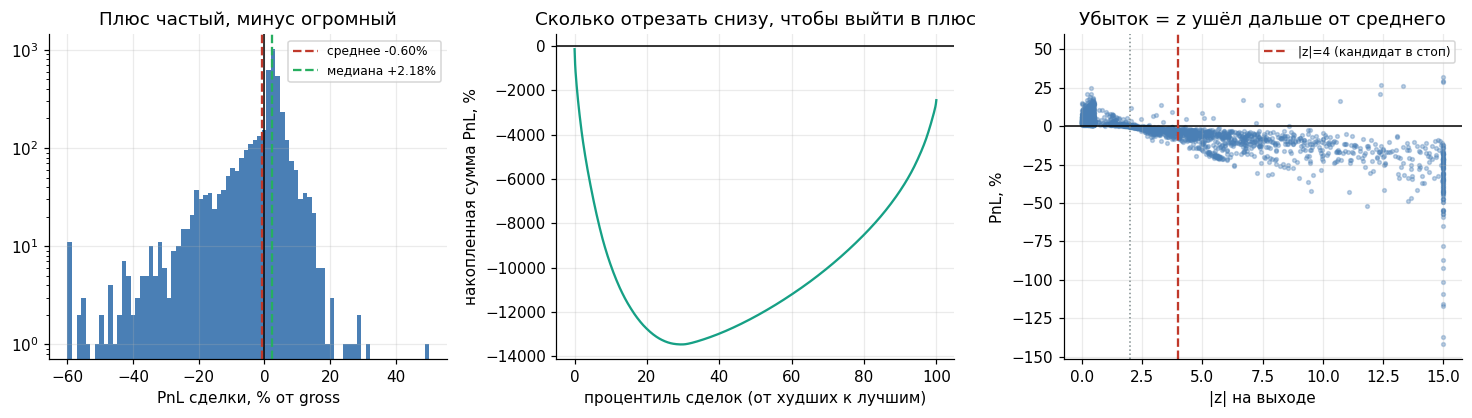

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
ax[0].hist(base.pnl.clip(-60, 60), bins=80, color="#4a7fb5", edgecolor="none")
ax[0].axvline(0, color="black", lw=1)
ax[0].axvline(base.pnl.mean(), color="#c0392b", ls="--", lw=1.5,
              label=f"среднее {base.pnl.mean():+.2f}%")
ax[0].axvline(base.pnl.median(), color="#27ae60", ls="--", lw=1.5,
              label=f"медиана {base.pnl.median():+.2f}%")
ax[0].set_yscale("log"); ax[0].set_xlabel("PnL сделки, % от gross")
ax[0].set_title("Плюс частый, минус огромный"); ax[0].legend(fontsize=8)

srt = np.sort(base.pnl.values)
ax[1].plot(np.arange(len(srt))/len(srt)*100, np.cumsum(srt), lw=1.5, color="#16a085")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("процентиль сделок (от худших к лучшим)")
ax[1].set_ylabel("накопленная сумма PnL, %")
ax[1].set_title("Сколько отрезать снизу, чтобы выйти в плюс")

ax[2].scatter(base.z_out.abs().clip(0, 15), base.pnl.clip(-150, 60), s=6, alpha=0.35,
              color="#4a7fb5")
ax[2].axhline(0, color="black", lw=1)
ax[2].axvline(2, color="#7f8c8d", ls=":", lw=1)
ax[2].axvline(4, color="#c0392b", ls="--", lw=1.5, label="|z|=4 (кандидат в стоп)")
ax[2].set_xlabel("|z| на выходе"); ax[2].set_ylabel("PnL, %")
ax[2].set_title("Убыток = z ушёл дальше от среднего"); ax[2].legend(fontsize=8)
show("nb03_diagnosis")

### 1b. Хвост — это НЕ 40 независимых событий

Прежде чем ставить стоп, надо понять: если весь убыток делают 40 сделок из 4068,
то сколько там **независимых** событий? Если это 40 разных дней и 40 разных
активов — статистика есть и стоп можно настраивать. Если это 3 рыночных эпизода,
где одна и та же нога взлетела против нас во всех парах сразу — то (1) выборка
для настройки стопа фактически n≈3, и (2) **диверсификация по парам не спасает**,
потому что все пары ломаются одновременно. Это ключевой вопрос для шага (b).

худшие 1% (40 сделок, сумма -2467%):
  различных месяцев торговли: 5 из 17; топ-3: {'2024-11': np.int64(18), '2024-03': np.int64(9), '2024-02': np.int64(7)}
  доля сделок в самом плохом месяце: 45%
  самая частая нога: XLMUSDT в 7 из 40 сделок (18%); топ-3 ног: {'XLMUSDT': np.int64(7), 'JASMYUSDT': np.int64(7), 'TONUSDT': np.int64(6)}

худшие 2% (81 сделок, сумма -3887%):
  различных месяцев торговли: 9 из 17; топ-3: {'2024-11': np.int64(42), '2024-03': np.int64(12), '2024-02': np.int64(10)}
  доля сделок в самом плохом месяце: 52%
  самая частая нога: JASMYUSDT в 11 из 81 сделок (14%); топ-3 ног: {'JASMYUSDT': np.int64(11), 'GMTUSDT': np.int64(11), 'TONUSDT': np.int64(9)}

худшие 5% (203 сделок, сумма -6748%):
  различных месяцев торговли: 13 из 17; топ-3: {'2024-11': np.int64(75), '2024-03': np.int64(29), '2024-02': np.int64(19)}
  доля сделок в самом плохом месяце: 37%
  самая частая нога: GMTUSDT в 25 из 203 сделок (12%); топ-3 ног: {'GMTUSDT': np.int64(25), 'PEOPLEUSDT': np.int64(

[saved] notebooks\statarb\_out\nb03_tail_cluster.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb03_tail_cluster.png')

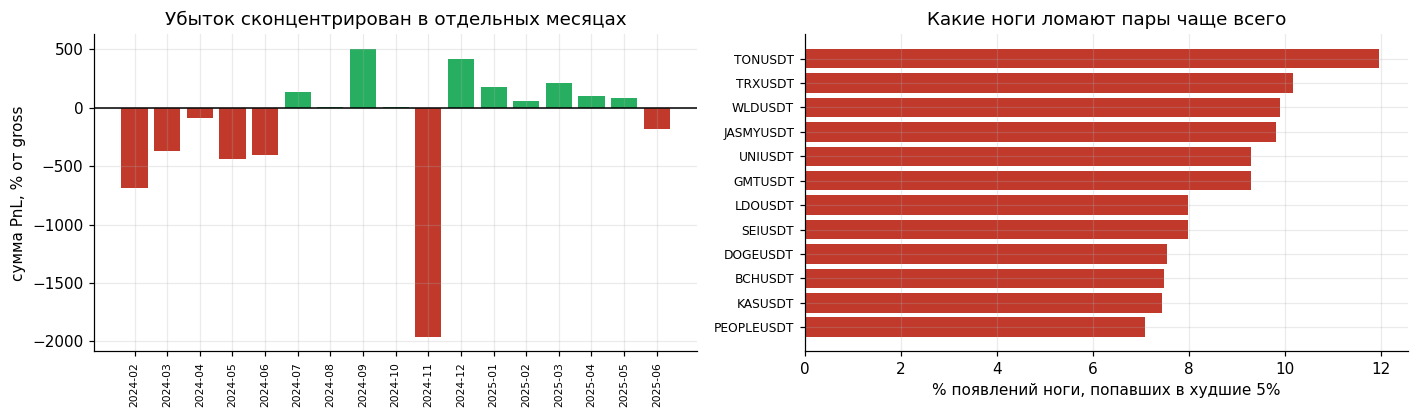

In [5]:
for q in [1, 2, 5]:
    k = max(1, int(len(b) * q / 100))
    t = b.iloc[:k]
    legs = pd.concat([t.pair.str.split("/").str[0], t.pair.str.split("/").str[1]])
    top_leg = legs.value_counts()
    top_mon = t.m_t.value_counts()
    print(f"худшие {q}% ({k} сделок, сумма {t.pnl.sum():+.0f}%):")
    print(f"  различных месяцев торговли: {t.m_t.nunique()} из {b.m_t.nunique()}; "
          f"топ-3: {dict(top_mon.head(3))}")
    print(f"  доля сделок в самом плохом месяце: {top_mon.iloc[0]/k*100:.0f}%")
    print(f"  самая частая нога: {top_leg.index[0]} в {top_leg.iloc[0]} из {k} сделок "
          f"({top_leg.iloc[0]/k*100:.0f}%); топ-3 ног: {dict(top_leg.head(3))}")
    print()

print("для сравнения — как распределены ВСЕ сделки:")
allm = b.m_t.value_counts()
print(f"  месяцев: {b.m_t.nunique()}, доля в самом активном месяце "
      f"{allm.iloc[0]/len(b)*100:.0f}%")

# одновременность: сколько убыточных позиций были открыты в один и тот же час
t5 = b.iloc[:int(len(b)*0.05)]
overlap = []
for _, r_ in t5.iterrows():
    same = t5[(t5.t_in <= r_.t_out) & (t5.t_out >= r_.t_in)]
    overlap.append(len(same))
print(f"\nсреди худших 5% сделок: медиана числа ОДНОВРЕМЕННО открытых "
      f"хвостовых позиций = {int(np.median(overlap))}")
print("-> хвост приходит кластером: много пар ломаются в один и тот же момент,")
print("   значит это общий рыночный эпизод, а не независимый риск отдельной пары.")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
mon = b.groupby("m_t").pnl.sum()
ax[0].bar(range(len(mon)), mon.values,
          color=["#c0392b" if v < 0 else "#27ae60" for v in mon.values])
ax[0].set_xticks(range(len(mon))); ax[0].set_xticklabels(mon.index, rotation=90, fontsize=7)
ax[0].axhline(0, color="black", lw=1); ax[0].set_ylabel("сумма PnL, % от gross")
ax[0].set_title("Убыток сконцентрирован в отдельных месяцах")

legs_all = pd.concat([b.pair.str.split("/").str[0], b.pair.str.split("/").str[1]])
t1 = b.iloc[:int(len(b)*0.05)]
legs_tail = pd.concat([t1.pair.str.split("/").str[0], t1.pair.str.split("/").str[1]])
share = (legs_tail.value_counts() / legs_all.value_counts()).dropna().sort_values()[-12:]
ax[1].barh(range(len(share)), share.values*100, color="#c0392b")
ax[1].set_yticks(range(len(share))); ax[1].set_yticklabels(share.index, fontsize=8)
ax[1].set_xlabel("% появлений ноги, попавших в худшие 5%")
ax[1].set_title("Какие ноги ломают пары чаще всего")
show("nb03_tail_cluster")

## 2. Варианты защиты

Все прогоны на одном наборе пар-месяцев, отличаются только правилами. Смотрим на
**среднее** и **среднее/std** (медиану уже знаем как ловушку), худшую сделку и
причины выхода.

In [6]:
VARIANTS = [
    ("0 базовый (nb02)", dict()),
    ("1 фильтр beta>0", dict(beta_filter=True)),
    ("2 beta>0 + b_lvl/b_ret в [0.5,2]", dict(beta_stab=(0.5, 2.0))),
    ("3 z-стоп 4", dict(zstop=4.0)),
    ("4 z-стоп 3", dict(zstop=3.0)),
    ("5 стоп -10% gross", dict(stop_pct=10.0)),
    ("6 стоп -5% gross", dict(stop_pct=5.0)),
    ("7 лимит 7 дней", dict(max_hold=24*7)),
    ("8 z-стоп 4 + без перезахода", dict(zstop=4.0, reenter=False)),
    ("9 beta>0 + z-стоп 4 + 7 дней", dict(beta_filter=True, zstop=4.0, max_hold=24*7)),
    ("10 всё вместе", dict(beta_stab=(0.5, 2.0), zstop=4.0, max_hold=24*7, reenter=False)),
]

rows, runs = [], {}
for tag, kw in VARIANTS:
    d = run_variant(SEL, **kw)
    runs[tag] = d
    bym = d.groupby("m_t").pnl.mean()
    rows.append({"вариант": tag, "сделок": len(d),
                 "среднее %": round(d.pnl.mean(), 3),
                 "медиана %": round(d.pnl.median(), 2),
                 "std": round(d.pnl.std(), 2),
                 "среднее/std": round(d.pnl.mean()/d.pnl.std(), 3),
                 "худшая %": round(d.pnl.min(), 1),
                 "q05 %": round(d.pnl.quantile(.05), 1),
                 "% плюс": round((d.pnl > 0).mean()*100, 1),
                 "мес +": f"{(bym>0).sum()}/{len(bym)}",
                 "медиана ч": int(d.hours.median())})
V = pd.DataFrame(rows)
print("ВАРИАНТЫ ЗАЩИТЫ (TRAIN, косты 21 bps учтены, PnL в % от gross notional)")
print(V.to_string(index=False))

ВАРИАНТЫ ЗАЩИТЫ (TRAIN, косты 21 bps учтены, PnL в % от gross notional)
                         вариант  сделок  среднее %  медиана %   std  среднее/std  худшая %  q05 %  % плюс мес +  медиана ч
                0 базовый (nb02)    4068     -0.600       2.18 10.46       -0.057    -142.0  -19.7    70.4 10/17        113
                 1 фильтр beta>0    3800     -0.566       2.12  9.79       -0.058    -142.0  -17.6    70.7 11/17        111
2 beta>0 + b_lvl/b_ret в [0.5,2]    3208     -0.437       2.04  9.10       -0.048    -142.0  -15.3    71.3  9/17        106
                      3 z-стоп 4   13111     -0.221      -0.64  3.51       -0.063     -27.4   -4.7    22.9  5/17          8
                      4 z-стоп 3   16090     -0.231      -0.65  2.66       -0.087     -16.3   -3.0    17.9  2/17          5
               5 стоп -10% gross    5425     -0.491       1.73  7.94       -0.062     -32.7  -12.3    60.3 10/17         85
                6 стоп -5% gross    7299     -0.442      -0.

In [7]:
print("ПРИЧИНЫ ВЫХОДА и средний PnL по каждой")
for tag in ["0 базовый (nb02)", "3 z-стоп 4", "6 стоп -5% gross", "10 всё вместе"]:
    d = runs[tag]
    g = d.groupby("reason").pnl.agg(["size", "mean"]).round(2)
    g["доля %"] = (g["size"]/len(d)*100).round(1)
    print(f"\n{tag}  (n={len(d)}, среднее {d.pnl.mean():+.3f}%)")
    print(g.to_string())

print("\n\nРЕЖЕТ ЛИ СТОП ПОБЕДИТЕЛЕЙ? сопоставляем те же входы со стопом и без")
d0, d3 = runs["0 базовый (nb02)"], runs["3 z-стоп 4"]
st = d3[d3.reason == "zstop"]
key0 = d0.set_index(["pair", "t_in"]).pnl
matched = key0.reindex(st.set_index(["pair", "t_in"]).index).dropna()
st_matched = st.set_index(["pair", "t_in"]).pnl.reindex(matched.index)
print(f"выбито z-стопом: {len(st)} сделок ({len(st)/len(d3)*100:.1f}%), "
      f"их средний PnL {st.pnl.mean():+.2f}%")
print(f"сопоставлено с базовым вариантом: {len(matched)}")
print(f"  БЕЗ стопа эти входы дали бы: среднее {matched.mean():+.2f}%, "
      f"медиана {matched.median():+.2f}%, плюсовых {(matched>0).mean()*100:.0f}%")
print(f"  СО стопом получили:          среднее {st_matched.mean():+.2f}%")
print(f"  => на этой подвыборке стоп "
      f"{'ПОМОГ' if st_matched.mean() > matched.mean() else 'НАВРЕДИЛ'} "
      f"({st_matched.mean() - matched.mean():+.2f} п.п.)")

ПРИЧИНЫ ВЫХОДА и средний PnL по каждой

0 базовый (nb02)  (n=4068, среднее -0.600%)
        size  mean  доля %
reason                    
forced  1399 -9.13    34.4
target  2669  3.87    65.6

3 z-стоп 4  (n=13111, среднее -0.221%)
        size  mean  доля %
reason                    
forced   536  0.60     4.1
target  2646  4.54    20.2
zstop   9929 -1.53    75.7

6 стоп -5% gross  (n=7299, среднее -0.442%)
          size  mean  доля %
reason                      
forced    1398  2.59    19.2
stop_pct  3232 -6.35    44.3
target    2669  5.13    36.6

10 всё вместе  (n=2790, среднее -0.044%)
        size  mean  доля %
reason                    
forced   148 -0.38     5.3
target  1158  3.19    41.5
time     473 -0.01    17.0
zstop   1011 -3.72    36.2


РЕЖЕТ ЛИ СТОП ПОБЕДИТЕЛЕЙ? сопоставляем те же входы со стопом и без
выбито z-стопом: 9929 сделок (75.7%), их средний PnL -1.53%
сопоставлено с базовым вариантом: 1785
  БЕЗ стопа эти входы дали бы: среднее -5.41%, медиана -2.19%, плюсовы

[saved] notebooks\statarb\_out\nb03_variants.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb03_variants.png')

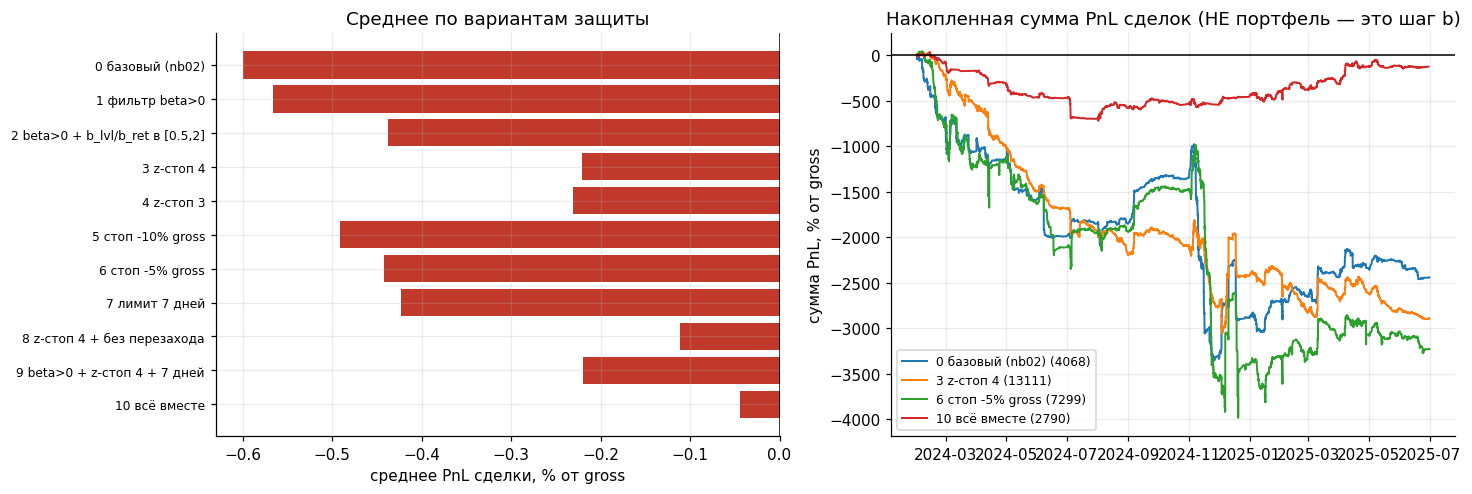

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
names = [r["вариант"] for r in rows]
vals = [r["среднее %"] for r in rows]
ax[0].barh(range(len(names)), vals, color=["#27ae60" if v > 0 else "#c0392b" for v in vals])
ax[0].set_yticks(range(len(names))); ax[0].set_yticklabels(names, fontsize=8)
ax[0].axvline(0, color="black", lw=1); ax[0].invert_yaxis()
ax[0].set_xlabel("среднее PnL сделки, % от gross")
ax[0].set_title("Среднее по вариантам защиты")

for tag in ["0 базовый (nb02)", "3 z-стоп 4", "6 стоп -5% gross", "10 всё вместе"]:
    d = runs[tag].sort_values("t_in")
    ax[1].plot(d.t_in.values, d.pnl.cumsum().values, lw=1.3, label=f"{tag} ({len(d)})")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_title("Накопленная сумма PnL сделок (НЕ портфель — это шаг b)")
ax[1].set_ylabel("сумма PnL, % от gross"); ax[1].legend(fontsize=8)
show("nb03_variants")